In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import seaborn as sns

In [4]:
np.random.seed(42)

In [15]:
X0 = np.random.normal(loc=[5, 5], scale=[1, 1], size=(50,2))
y0 = np.zeros(50)

In [16]:
X1 = np.random.normal(loc=[7, 3], scale=[1, 1], size=(50,2))
y1 = np.ones(50)

In [17]:
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

In [18]:
df = pd.DataFrame(X, columns=['Sweetness', 'Crunchiness'])
df['Class'] = y

In [19]:
display(df.head())

,Sweetness,Crunchiness,Class
0,5.926178,6.909417,0.0
1,3.601432,5.562969,0.0
2,4.349357,4.512875,0.0
3,4.407606,4.136009,0.0
4,5.048522,4.169050,0.0


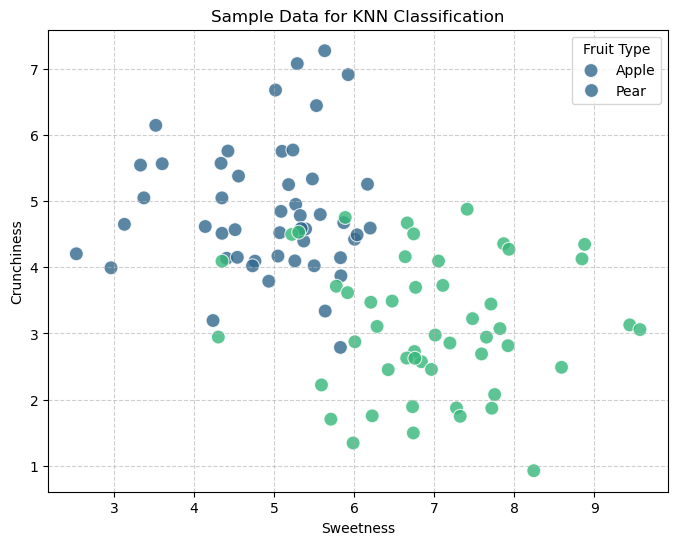

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sweetness', y='Crunchiness', hue='Class', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Sample Data for KNN Classification')
plt.xlabel('Sweetness')
plt.ylabel('Crunchiness')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Fruit Type', loc='upper right', labels=['Apple', 'Pear'])
plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (70, 2), (70,)
Testing set shape: (30, 2), (30,)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training features (first 5 rows):\n", X_train_scaled[:5])

Scaled training features (first 5 rows):
 [[-1.2618012   1.31044258]
 [-0.03510794  0.44740426]
 [ 1.55839012 -2.39850104]
 [-1.13552346  0.50926663]
 [ 0.48592289 -1.04193057]]


In [23]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully with k=5.")

KNN model trained successfully with k=5.


In [24]:
y_pred = knn.predict(X_test_scaled)

print("First 10 actual labels:", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])

First 10 actual labels: [1. 1. 1. 0. 0. 0. 0. 1. 0. 0.]
First 10 predicted labels: [0. 1. 0. 0. 0. 0. 0. 1. 0. 0.]


In [27]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.83
